In [1]:
# ═══════════════════════════════════════════════════════════════════════
# ISE 503 - Health Analytics | Spring 2026
# Project: Predicting High-Cost Medicare Patients Before They Become High-Cost
# Team: Vansh Chanchlani & Sagarika Raju
# ═══════════════════════════════════════════════════════════════════════

# ── IMPORTS ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, classification_report,
                             roc_curve, precision_recall_curve,
                             average_precision_score, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('muted')

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


In [2]:
# ── LOAD BENEFICIARY FILES ─────────────────────────────────────────────
bene_2022 = pd.read_csv('../datasets/beneficiary_2022.csv', sep='|')
bene_2023 = pd.read_csv('../datasets/beneficiary_2023.csv', sep='|')

print("Beneficiary 2022 shape:", bene_2022.shape)
print("Beneficiary 2023 shape:", bene_2023.shape)

# ── LOAD CLAIMS FILES ──────────────────────────────────────────────────
print("\nLoading claims files...")

inp_full = pd.read_csv('../datasets/inpatient.csv', sep='|',
                       usecols=['BENE_ID', 'CLM_FROM_DT', 'CLM_PMT_AMT',
                                'CLM_TOT_CHRG_AMT', 'CLM_UTLZTN_DAY_CNT'])

out_full = pd.read_csv('../datasets/outpatient.csv', sep='|',
                       usecols=['BENE_ID', 'CLM_FROM_DT', 'CLM_PMT_AMT',
                                'CLM_TOT_CHRG_AMT'])

car_full = pd.read_csv('../datasets/carrier.csv', sep='|',
                       usecols=['BENE_ID', 'CLM_FROM_DT', 'CLM_PMT_AMT'])

# Parse dates and extract year
for df in [inp_full, out_full, car_full]:
    df['CLM_FROM_DT'] = pd.to_datetime(df['CLM_FROM_DT'], errors='coerce')
    df['YEAR'] = df['CLM_FROM_DT'].dt.year

print("✓ Inpatient:", inp_full.shape)
print("✓ Outpatient:", out_full.shape)
print("✓ Carrier:", car_full.shape)
print("\nClaims years available:", sorted(inp_full['YEAR'].dropna().unique()))

Beneficiary 2022 shape: (8671, 185)
Beneficiary 2023 shape: (9179, 185)

Loading claims files...
✓ Inpatient: (58066, 6)
✓ Outpatient: (575092, 5)
✓ Carrier: (1121004, 4)

Claims years available: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [3]:
# ── BUILD YEAR 1 (2022) AND YEAR 2 (2023) SPENDING ────────────────────

def get_spending_by_year(inp, out, car, year):
    """Aggregate total Medicare payments per beneficiary for a given year."""
    
    inp_yr = inp[inp['YEAR'] == year].groupby('BENE_ID').agg(
        INP_PMT=('CLM_PMT_AMT', 'sum'),
        INP_STAYS=('CLM_PMT_AMT', 'count'),
        INP_DAYS=('CLM_UTLZTN_DAY_CNT', 'sum')
    ).reset_index()

    out_yr = out[out['YEAR'] == year].groupby('BENE_ID').agg(
        OUT_PMT=('CLM_PMT_AMT', 'sum'),
        OUT_VISITS=('CLM_PMT_AMT', 'count')
    ).reset_index()

    car_yr = car[car['YEAR'] == year].groupby('BENE_ID').agg(
        CAR_PMT=('CLM_PMT_AMT', 'sum'),
        CAR_CLAIMS=('CLM_PMT_AMT', 'count')
    ).reset_index()

    spending = inp_yr.merge(out_yr, on='BENE_ID', how='outer')\
                     .merge(car_yr, on='BENE_ID', how='outer')
    spending = spending.fillna(0)
    spending['TOTAL_PMT'] = spending['INP_PMT'] + spending['OUT_PMT'] + spending['CAR_PMT']
    return spending

# Build spending for Year 1 and Year 2
spend_2022 = get_spending_by_year(inp_full, out_full, car_full, 2022)
spend_2023 = get_spending_by_year(inp_full, out_full, car_full, 2023)

print("Year 1 (2022) beneficiaries with claims:", len(spend_2022))
print("Year 2 (2023) beneficiaries with claims:", len(spend_2023))

print("\nYear 1 spending summary:")
print(spend_2022['TOTAL_PMT'].describe().round(2))

print("\nYear 2 spending summary:")
print(spend_2023['TOTAL_PMT'].describe().round(2))

# ── CREATE HIGH-COST LABEL FROM YEAR 2 ────────────────────────────────
threshold = spend_2023['TOTAL_PMT'].quantile(0.95)
spend_2023['HIGH_COST'] = (spend_2023['TOTAL_PMT'] >= threshold).astype(int)

print(f"\nTop 5% spending threshold (Year 2): ${threshold:,.2f}")
print("High cost patients (1):", spend_2023['HIGH_COST'].sum())
print("Non high cost patients (0):", (spend_2023['HIGH_COST']==0).sum())
print("\nClass distribution:")
print(spend_2023['HIGH_COST'].value_counts(normalize=True).round(3))

Year 1 (2022) beneficiaries with claims: 8301
Year 2 (2023) beneficiaries with claims: 3494

Year 1 spending summary:
count        8301.00
mean        85401.79
std        500934.23
min             0.00
25%         11223.50
50%         21719.90
75%         60013.50
max      19454109.68
Name: TOTAL_PMT, dtype: float64

Year 2 spending summary:
count       3494.00
mean       35375.67
std       197069.61
min            0.00
25%         4688.66
50%        13519.76
75%        24700.57
max      8864826.79
Name: TOTAL_PMT, dtype: float64

Top 5% spending threshold (Year 2): $85,797.90
High cost patients (1): 175
Non high cost patients (0): 3319

Class distribution:
HIGH_COST
0    0.95
1    0.05
Name: proportion, dtype: float64


In [4]:
# ── MERGE BENEFICIARY DEMOGRAPHICS WITH SPENDING ───────────────────────

# Select useful demographic columns from beneficiary 2022
demo_cols = ['BENE_ID', 'AGE_AT_END_REF_YR', 'SEX_IDENT_CD', 'BENE_RACE_CD',
             'ESRD_IND', 'DUAL_ELGBL_MONS', 'BENE_HI_CVRAGE_TOT_MONS',
             'BENE_SMI_CVRAGE_TOT_MONS', 'BENE_HMO_CVRAGE_TOT_MONS',
             'BENE_STATE_BUYIN_TOT_MONS', 'RTI_RACE_CD']

bene_demo = bene_2022[demo_cols].copy()

# Merge Year 1 spending with demographics
df_y1 = spend_2022.merge(bene_demo, on='BENE_ID', how='inner')

# Merge with Year 2 label
label = spend_2023[['BENE_ID', 'HIGH_COST', 'TOTAL_PMT']].rename(
    columns={'TOTAL_PMT': 'Y2_TOTAL_PMT'})

df_final = df_y1.merge(label, on='BENE_ID', how='inner')

print("Final dataset shape:", df_final.shape)
print("\nClass distribution in final dataset:")
print(df_final['HIGH_COST'].value_counts())
print("\nMissing values:")
print(df_final.isnull().sum()[df_final.isnull().sum() > 0])
print("\nSample:")
print(df_final.head(3).to_string())

Final dataset shape: (3339, 21)

Class distribution in final dataset:
HIGH_COST
0    3172
1     167
Name: count, dtype: int64

Missing values:
Series([], dtype: int64)

Sample:
          BENE_ID  INP_PMT  INP_STAYS  INP_DAYS    OUT_PMT  OUT_VISITS    CAR_PMT  CAR_CLAIMS  TOTAL_PMT  AGE_AT_END_REF_YR  SEX_IDENT_CD  BENE_RACE_CD ESRD_IND  DUAL_ELGBL_MONS  BENE_HI_CVRAGE_TOT_MONS  BENE_SMI_CVRAGE_TOT_MONS  BENE_HMO_CVRAGE_TOT_MONS  BENE_STATE_BUYIN_TOT_MONS  RTI_RACE_CD  HIGH_COST  Y2_TOTAL_PMT
0 -10000010287996     0.00        0.0       0.0  125687.59       112.0   46881.82        23.0  172569.41                 55             2             5        Y                0                       12                        12                         0                         12            5          0      25150.04
1 -10000010287992   166.97        1.0       1.0    1365.04         2.0   29496.80        16.0   31028.81                 83             1             1        0                0      

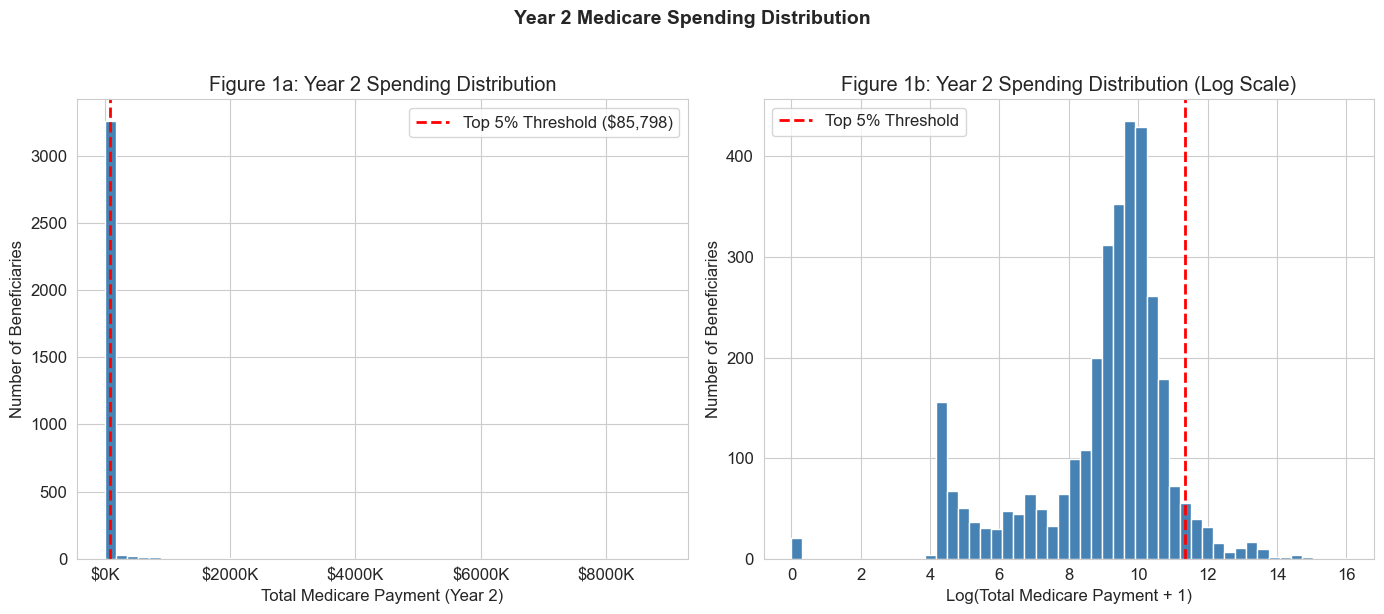

✓ Figure 1 saved


In [5]:
# ── EDA: FIGURE 1 - YEAR 2 SPENDING DISTRIBUTION ──────────────────────
import os
os.makedirs('../outputs', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: full distribution
axes[0].hist(df_final['Y2_TOTAL_PMT'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df_final['Y2_TOTAL_PMT'].quantile(0.95),
                color='red', linestyle='--', linewidth=2, label='Top 5% Threshold ($85,798)')
axes[0].set_xlabel('Total Medicare Payment (Year 2)')
axes[0].set_ylabel('Number of Beneficiaries')
axes[0].set_title('Figure 1a: Year 2 Spending Distribution')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].legend()

# Right: log scale for better visibility
axes[1].hist(np.log1p(df_final['Y2_TOTAL_PMT']), bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(np.log1p(df_final['Y2_TOTAL_PMT'].quantile(0.95)),
                color='red', linestyle='--', linewidth=2, label='Top 5% Threshold')
axes[1].set_xlabel('Log(Total Medicare Payment + 1)')
axes[1].set_ylabel('Number of Beneficiaries')
axes[1].set_title('Figure 1b: Year 2 Spending Distribution (Log Scale)')
axes[1].legend()

plt.suptitle('Year 2 Medicare Spending Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figure1_spending_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 1 saved")

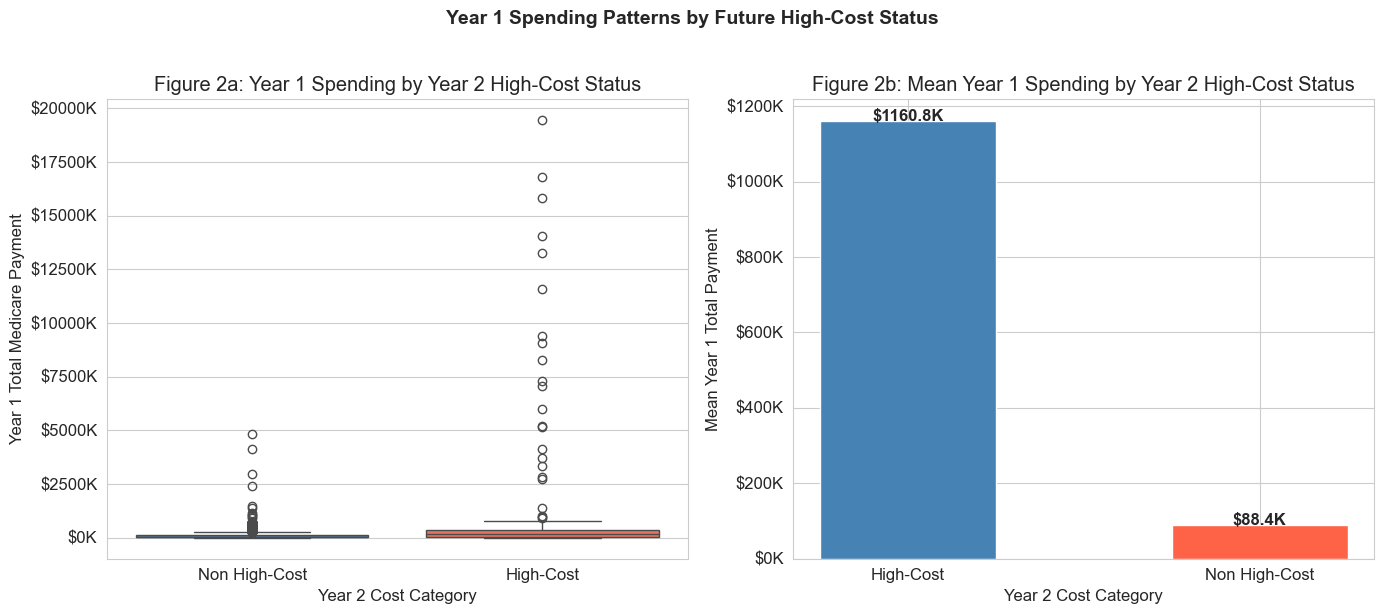

✓ Figure 2 saved


In [6]:
# ── EDA: FIGURE 2 - YEAR 1 SPENDING BY HIGH-COST STATUS ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: boxplot
df_final['HIGH_COST_LABEL'] = df_final['HIGH_COST'].map({0: 'Non High-Cost', 1: 'High-Cost'})

sns.boxplot(data=df_final, x='HIGH_COST_LABEL', y='TOTAL_PMT',
            palette={'Non High-Cost': 'steelblue', 'High-Cost': 'tomato'},
            ax=axes[0])
axes[0].set_xlabel('Year 2 Cost Category')
axes[0].set_ylabel('Year 1 Total Medicare Payment')
axes[0].set_title('Figure 2a: Year 1 Spending by Year 2 High-Cost Status')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Right: mean spending comparison bar chart
mean_spend = df_final.groupby('HIGH_COST_LABEL')['TOTAL_PMT'].mean().reset_index()
bars = axes[1].bar(mean_spend['HIGH_COST_LABEL'], mean_spend['TOTAL_PMT'],
                   color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
axes[1].set_xlabel('Year 2 Cost Category')
axes[1].set_ylabel('Mean Year 1 Total Payment')
axes[1].set_title('Figure 2b: Mean Year 1 Spending by Year 2 High-Cost Status')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
for bar, val in zip(bars, mean_spend['TOTAL_PMT']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'${val/1000:.1f}K', ha='center', fontweight='bold')

plt.suptitle('Year 1 Spending Patterns by Future High-Cost Status',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figure2_spending_by_label.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 2 saved")

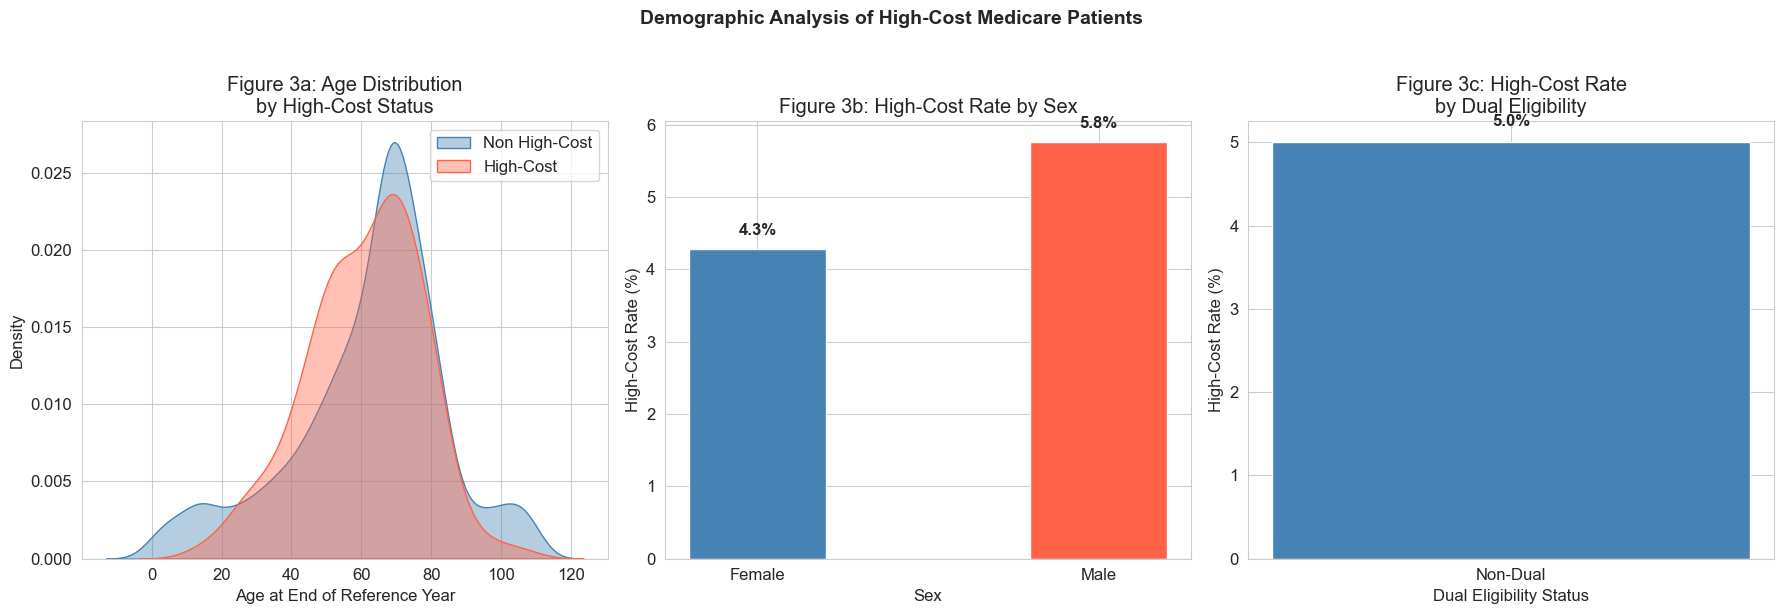

✓ Figure 3 saved


In [7]:
# ── EDA: FIGURE 3 - DEMOGRAPHIC ANALYSIS ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: Age distribution by high-cost status
sns.kdeplot(data=df_final[df_final['HIGH_COST']==0],
            x='AGE_AT_END_REF_YR', ax=axes[0],
            label='Non High-Cost', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(data=df_final[df_final['HIGH_COST']==1],
            x='AGE_AT_END_REF_YR', ax=axes[0],
            label='High-Cost', color='tomato', fill=True, alpha=0.4)
axes[0].set_xlabel('Age at End of Reference Year')
axes[0].set_ylabel('Density')
axes[0].set_title('Figure 3a: Age Distribution\nby High-Cost Status')
axes[0].legend()

# Middle: Sex breakdown
sex_map = {1: 'Male', 2: 'Female'}
df_final['SEX_LABEL'] = df_final['SEX_IDENT_CD'].map(sex_map)
sex_pct = df_final.groupby('SEX_LABEL')['HIGH_COST'].mean().reset_index()
sex_pct.columns = ['Sex', 'High_Cost_Rate']
bars = axes[1].bar(sex_pct['Sex'], sex_pct['High_Cost_Rate']*100,
                   color=['steelblue', 'tomato'], edgecolor='white', width=0.4)
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('High-Cost Rate (%)')
axes[1].set_title('Figure 3b: High-Cost Rate by Sex')
for bar, val in zip(bars, sex_pct['High_Cost_Rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{val*100:.1f}%', ha='center', fontweight='bold')

# Right: Dual eligibility
df_final['DUAL_FLAG'] = (df_final['DUAL_ELGBL_MONS'] > 0).map(
    {True: 'Dual Eligible', False: 'Non-Dual'})
dual_pct = df_final.groupby('DUAL_FLAG')['HIGH_COST'].mean().reset_index()
bars2 = axes[2].bar(dual_pct['DUAL_FLAG'], dual_pct['HIGH_COST']*100,
                    color=['steelblue', 'tomato'], edgecolor='white', width=0.4)
axes[2].set_xlabel('Dual Eligibility Status')
axes[2].set_ylabel('High-Cost Rate (%)')
axes[2].set_title('Figure 3c: High-Cost Rate\nby Dual Eligibility')
for bar, val in zip(bars2, dual_pct['HIGH_COST']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{val*100:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Demographic Analysis of High-Cost Medicare Patients',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figure3_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved")

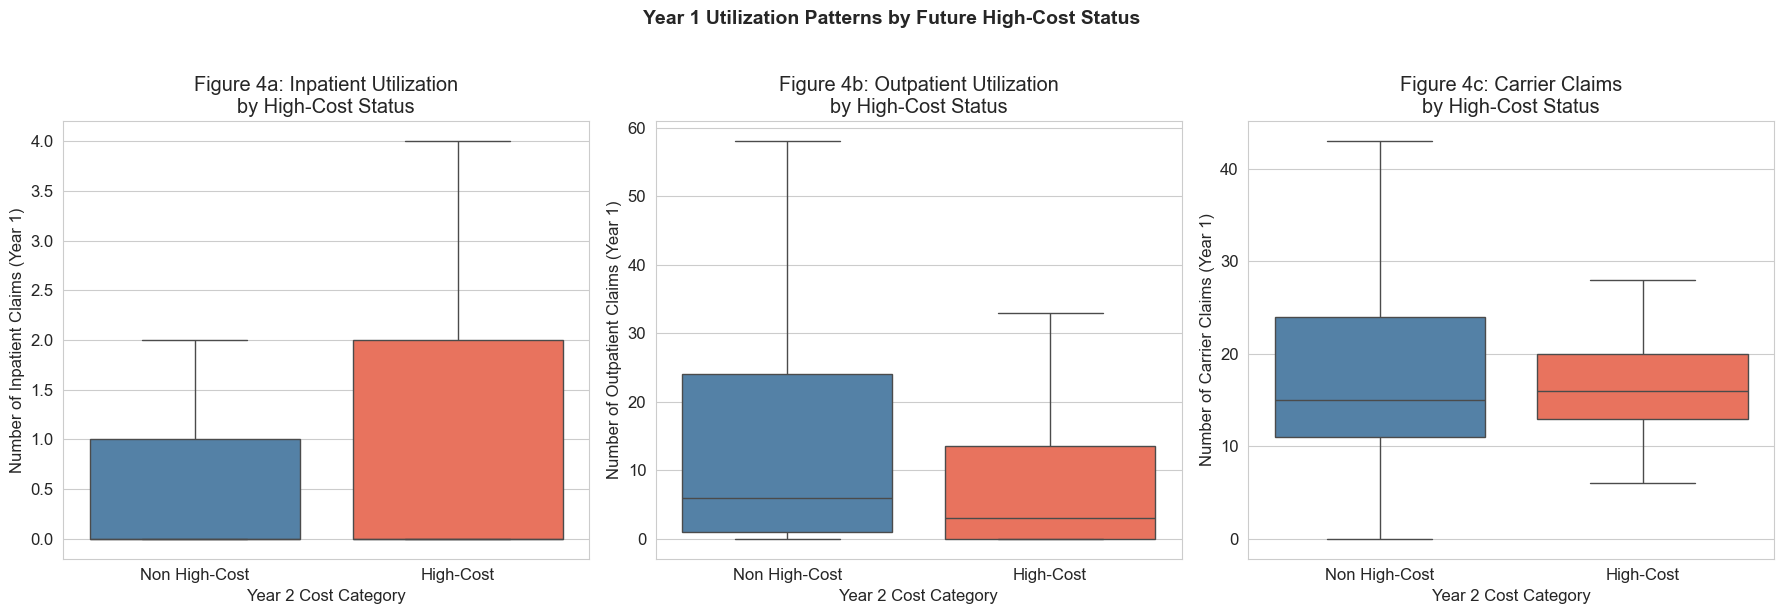

Mean utilization by high-cost status:
                 INP_STAYS  OUT_VISITS  CAR_CLAIMS
HIGH_COST_LABEL                                   
High-Cost             10.3        16.8        30.3
Non High-Cost          2.0        23.3        30.0
✓ Figure 4 saved


In [8]:
# ── EDA: FIGURE 4 - UTILIZATION PATTERNS ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: Inpatient stays by high-cost status
sns.boxplot(data=df_final, x='HIGH_COST_LABEL', y='INP_STAYS',
            palette={'Non High-Cost': 'steelblue', 'High-Cost': 'tomato'},
            ax=axes[0], showfliers=False)
axes[0].set_xlabel('Year 2 Cost Category')
axes[0].set_ylabel('Number of Inpatient Claims (Year 1)')
axes[0].set_title('Figure 4a: Inpatient Utilization\nby High-Cost Status')

# Middle: Outpatient visits
sns.boxplot(data=df_final, x='HIGH_COST_LABEL', y='OUT_VISITS',
            palette={'Non High-Cost': 'steelblue', 'High-Cost': 'tomato'},
            ax=axes[1], showfliers=False)
axes[1].set_xlabel('Year 2 Cost Category')
axes[1].set_ylabel('Number of Outpatient Claims (Year 1)')
axes[1].set_title('Figure 4b: Outpatient Utilization\nby High-Cost Status')

# Right: Carrier claims
sns.boxplot(data=df_final, x='HIGH_COST_LABEL', y='CAR_CLAIMS',
            palette={'Non High-Cost': 'steelblue', 'High-Cost': 'tomato'},
            ax=axes[2], showfliers=False)
axes[2].set_xlabel('Year 2 Cost Category')
axes[2].set_ylabel('Number of Carrier Claims (Year 1)')
axes[2].set_title('Figure 4c: Carrier Claims\nby High-Cost Status')

plt.suptitle('Year 1 Utilization Patterns by Future High-Cost Status',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figure4_utilization.png', dpi=150, bbox_inches='tight')
plt.show()

# Print mean utilization stats
print("Mean utilization by high-cost status:")
print(df_final.groupby('HIGH_COST_LABEL')[['INP_STAYS','OUT_VISITS','CAR_CLAIMS']].mean().round(1))
print("✓ Figure 4 saved")

After SMOTE - Class distribution:
HIGH_COST
0    2220
1    2220
Name: count, dtype: int64

✓ Logistic Regression AUC-ROC: 0.8283


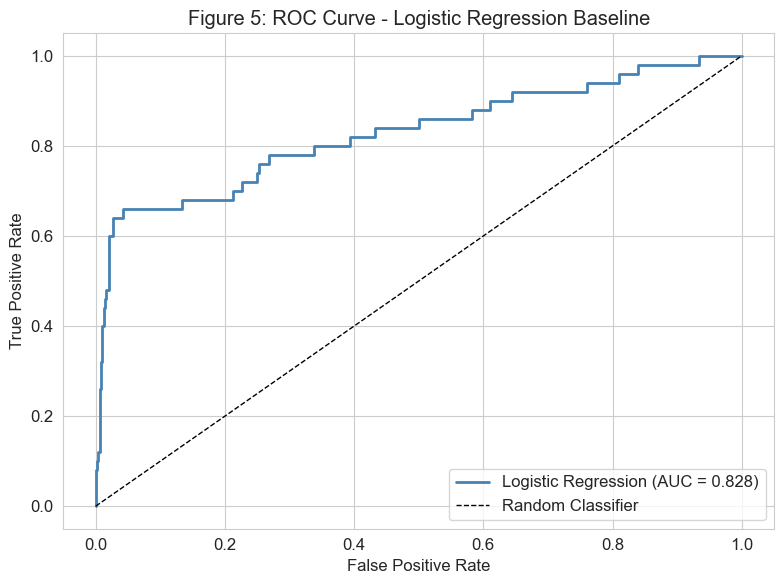


Classification Report:
               precision    recall  f1-score   support

Non High-Cost       0.98      0.96      0.97       952
    High-Cost       0.44      0.64      0.52        50

     accuracy                           0.94      1002
    macro avg       0.71      0.80      0.75      1002
 weighted avg       0.95      0.94      0.95      1002

✓ Figure 5 saved


In [9]:
# ── CELL 9: BASELINE LOGISTIC REGRESSION ──────────────────────────────

# Feature columns
feature_cols = ['TOTAL_PMT', 'INP_PMT', 'OUT_PMT', 'CAR_PMT',
                'INP_STAYS', 'INP_DAYS', 'OUT_VISITS', 'CAR_CLAIMS',
                'AGE_AT_END_REF_YR', 'SEX_IDENT_CD', 'BENE_RACE_CD',
                'BENE_HI_CVRAGE_TOT_MONS', 'BENE_SMI_CVRAGE_TOT_MONS',
                'BENE_HMO_CVRAGE_TOT_MONS']

X = df_final[feature_cols]
y = df_final['HIGH_COST']

# Train/test split (70/30, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
print("After SMOTE - Class distribution:")
print(pd.Series(y_train_sm).value_counts())

# Fit Logistic Regression
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

# Evaluate
y_pred_proba = lr.predict_proba(X_test_sc)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n✓ Logistic Regression AUC-ROC: {auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'Logistic Regression (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 5: ROC Curve - Logistic Regression Baseline')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figure5_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
y_pred = lr.predict(X_test_sc)
print(classification_report(y_test, y_pred, target_names=['Non High-Cost', 'High-Cost']))
print("✓ Figure 5 saved")

XGBoost AUC-ROC: 0.7958
Logistic Regression AUC-ROC: 0.8283
Improvement: -0.0325


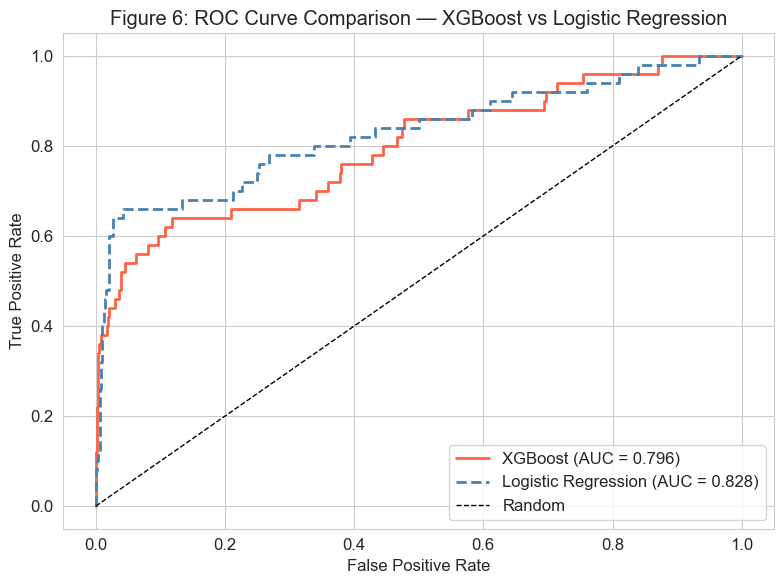


XGBoost Classification Report:
               precision    recall  f1-score   support

Non High-Cost       0.98      0.76      0.86       952
    High-Cost       0.13      0.66      0.21        50

     accuracy                           0.76      1002
    macro avg       0.55      0.71      0.53      1002
 weighted avg       0.93      0.76      0.82      1002



In [10]:
# ── CELL 10: XGBOOST MODEL ─────────────────────────────────────────────
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Features and target
feature_cols = ['TOTAL_PMT', 'INP_PMT', 'OUT_PMT', 'CAR_PMT',
                'INP_STAYS', 'INP_DAYS', 'OUT_VISITS', 'CAR_CLAIMS',
                'AGE_AT_END_REF_YR', 'SEX_IDENT_CD', 'BENE_RACE_CD',
                'BENE_HI_CVRAGE_TOT_MONS', 'BENE_SMI_CVRAGE_TOT_MONS',
                'BENE_HMO_CVRAGE_TOT_MONS']

X = df_final[feature_cols]
y = df_final['HIGH_COST']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# SMOTE on training only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=19,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train_sm, y_train_sm)

# Evaluate
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"XGBoost AUC-ROC: {auc_xgb:.4f}")
print(f"Logistic Regression AUC-ROC: 0.8283")
print(f"Improvement: {auc_xgb - 0.8283:.4f}")

# ROC curve comparison
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_xgb, tpr_xgb, color='tomato', lw=2,
        label=f'XGBoost (AUC = {auc_xgb:.3f})')
ax.plot(fpr_lr, tpr_lr, color='steelblue', lw=2, linestyle='--',
        label=f'Logistic Regression (AUC = 0.828)')
ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 6: ROC Curve Comparison — XGBoost vs Logistic Regression')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figure6_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nXGBoost Classification Report:")
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb,
      target_names=['Non High-Cost', 'High-Cost']))

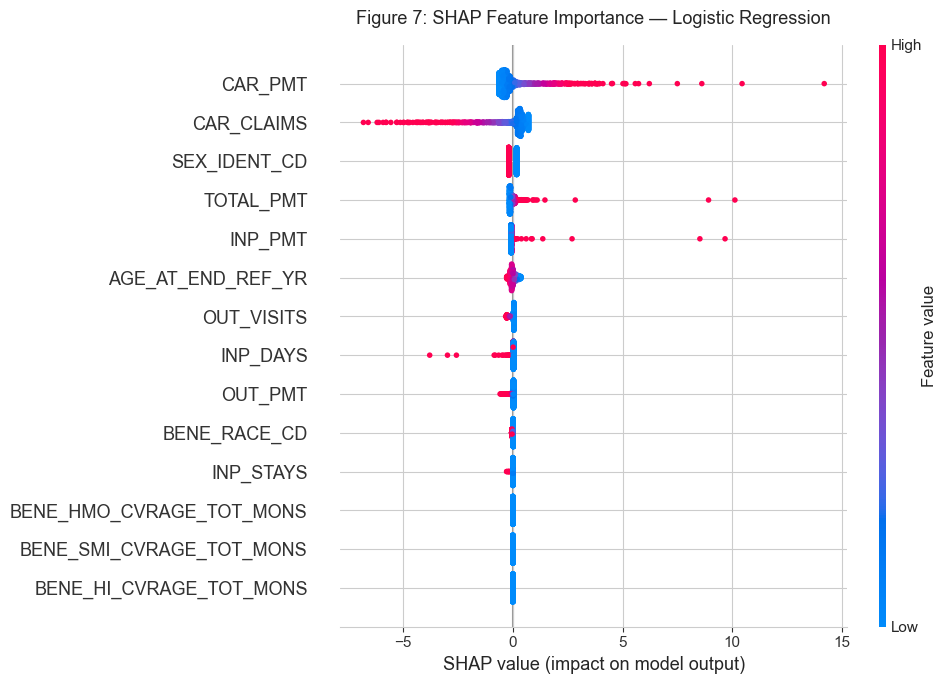

✓ Figure 7 saved


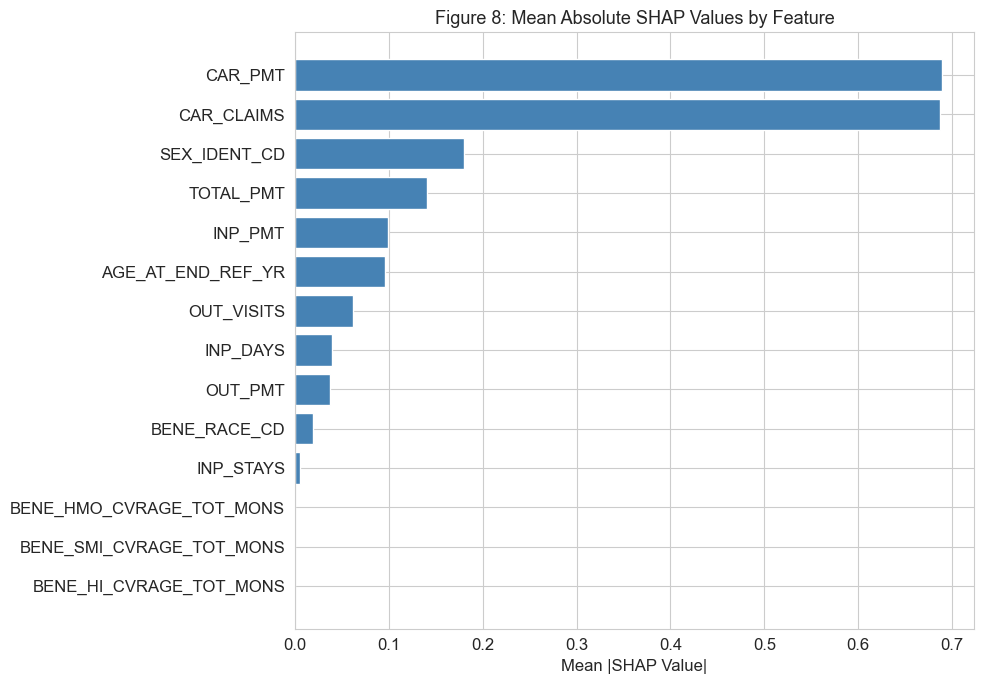

✓ Figure 8 saved

Top 5 features by SHAP importance:
     Feature  Mean_SHAP
     CAR_PMT   0.688776
  CAR_CLAIMS   0.686597
SEX_IDENT_CD   0.179929
   TOTAL_PMT   0.140955
     INP_PMT   0.098972


In [11]:
# ── CELL 11: SHAP ANALYSIS ON LOGISTIC REGRESSION ─────────────────────
import shap

# Use a linear explainer for Logistic Regression
explainer = shap.LinearExplainer(lr, X_train_sc, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_sc)

# Convert to DataFrame for plotting
X_test_display = pd.DataFrame(X_test_sc, columns=feature_cols)

# Global feature importance — beeswarm plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_display, feature_names=feature_cols,
                  show=False, plot_size=(10, 7))
plt.title("Figure 7: SHAP Feature Importance — Logistic Regression", fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../outputs/figure7_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 7 saved")

# Bar plot of mean absolute SHAP values
shap_df = pd.DataFrame({
    'Feature': feature_cols,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(shap_df['Feature'], shap_df['Mean_SHAP'], color='steelblue', edgecolor='white')
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Figure 8: Mean Absolute SHAP Values by Feature', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figure8_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 8 saved")
print("\nTop 5 features by SHAP importance:")
print(shap_df.tail(5)[['Feature','Mean_SHAP']].iloc[::-1].to_string(index=False))

In [12]:
# ── CELL 12: LOAD ADDITIONAL CLAIMS COLUMNS FOR FEATURE ENGINEERING ───
print("Reloading claims with diagnosis and utilization columns...")

# Reload inpatient with ICD codes + admission type
inp_rich = pd.read_csv('../datasets/inpatient.csv', sep='|',
                       usecols=['BENE_ID', 'CLM_FROM_DT',
                                'CLM_PMT_AMT', 'CLM_UTLZTN_DAY_CNT',
                                'CLM_IP_ADMSN_TYPE_CD', 'CLM_ADMSN_DT',
                                'CLM_THRU_DT',
                                'ICD_DGNS_CD1','ICD_DGNS_CD2','ICD_DGNS_CD3',
                                'ICD_DGNS_CD4','ICD_DGNS_CD5','ICD_DGNS_CD6',
                                'ICD_DGNS_CD7','ICD_DGNS_CD8','ICD_DGNS_CD9',
                                'ICD_DGNS_CD10'])

# Reload outpatient with ICD codes
out_rich = pd.read_csv('../datasets/outpatient.csv', sep='|',
                       usecols=['BENE_ID', 'CLM_FROM_DT', 'CLM_PMT_AMT',
                                'ICD_DGNS_CD1','ICD_DGNS_CD2','ICD_DGNS_CD3',
                                'ICD_DGNS_CD4','ICD_DGNS_CD5'])

# Reload carrier with specialty
car_rich = pd.read_csv('../datasets/carrier.csv', sep='|',
                       usecols=['BENE_ID', 'CLM_FROM_DT',
                                'CLM_PMT_AMT', 'PRVDR_SPCLTY'])

# Parse dates
for df in [inp_rich, out_rich, car_rich]:
    df['CLM_FROM_DT'] = pd.to_datetime(df['CLM_FROM_DT'], errors='coerce')
    df['YEAR'] = df['CLM_FROM_DT'].dt.year

print("✓ Inpatient rich:", inp_rich.shape)
print("✓ Outpatient rich:", out_rich.shape)
print("✓ Carrier rich:", car_rich.shape)
print("\nSample admission types:", inp_rich['CLM_IP_ADMSN_TYPE_CD'].value_counts().head())
print("Sample specialties:", car_rich['PRVDR_SPCLTY'].value_counts().head())

Reloading claims with diagnosis and utilization columns...
✓ Inpatient rich: (58066, 18)
✓ Outpatient rich: (575092, 9)
✓ Carrier rich: (1121004, 5)

Sample admission types: CLM_IP_ADMSN_TYPE_CD
1    43089
3    14020
2      957
Name: count, dtype: int64
Sample specialties: PRVDR_SPCLTY
1    1121004
Name: count, dtype: int64


In [13]:
# ── CELL 14: ADVANCED FEATURE ENGINEERING ─────────────────────────────

YEAR1 = 2022

# ── ICD CODE DISEASE CATEGORY MAPPING ─────────────────────────────────
# ICD-10 prefixes mapped to 8 chronic disease categories
disease_map = {
    'cardiovascular': ['I0','I1','I2','I3','I4','I5','I6','I7','I8','I9'],
    'diabetes':       ['E08','E09','E10','E11','E12','E13'],
    'respiratory':    ['J4','J6','J7','J8','J9'],
    'musculoskeletal':['M0','M1','M2','M3','M4','M5','M6','M7','M8'],
    'mental_health':  ['F0','F1','F2','F3','F4','F5','F6','F7','F8','F9'],
    'cancer':         ['C0','C1','C2','C3','C4','C5','C6','C7','C8','C9'],
    'renal':          ['N1','N2','N3','N4'],
    'neurological':   ['G0','G1','G2','G3','G4','G5','G6','G7','G8','G9']
}

def categorize_icd(code):
    """Return list of disease categories matching an ICD code."""
    if pd.isna(code):
        return []
    code = str(code).strip().upper()
    cats = []
    for cat, prefixes in disease_map.items():
        if any(code.startswith(p) for p in prefixes):
            cats.append(cat)
    return cats

# ── FUNCTION: BUILD RICH FEATURES FOR A GIVEN YEAR ────────────────────
def build_rich_features(inp, out, car, year):
    inp_yr = inp[inp['YEAR'] == year].copy()
    out_yr = out[out['YEAR'] == year].copy()
    car_yr = car[car['YEAR'] == year].copy()

    results = {}

    # ── 1. EMERGENCY ADMISSIONS ────────────────────────────────────────
    emerg = inp_yr[inp_yr['CLM_IP_ADMSN_TYPE_CD'] == 1]
    emerg_cnt = emerg.groupby('BENE_ID').size().reset_index(name='EMERG_ADMITS')
    results['emerg'] = emerg_cnt

    # ── 2. ELECTIVE ADMISSIONS ─────────────────────────────────────────
    elec = inp_yr[inp_yr['CLM_IP_ADMSN_TYPE_CD'] == 3]
    elec_cnt = elec.groupby('BENE_ID').size().reset_index(name='ELEC_ADMITS')
    results['elec'] = elec_cnt

    # ── 3. 30-DAY READMISSION FLAG ─────────────────────────────────────
    inp_sorted = inp_yr[['BENE_ID','CLM_ADMSN_DT','CLM_THRU_DT']].copy()
    inp_sorted['CLM_ADMSN_DT'] = pd.to_datetime(inp_sorted['CLM_ADMSN_DT'], errors='coerce')
    inp_sorted['CLM_THRU_DT'] = pd.to_datetime(inp_sorted['CLM_THRU_DT'], errors='coerce')
    inp_sorted = inp_sorted.sort_values(['BENE_ID','CLM_ADMSN_DT'])
    inp_sorted['PREV_DISCH'] = inp_sorted.groupby('BENE_ID')['CLM_THRU_DT'].shift(1)
    inp_sorted['DAYS_SINCE_DISCH'] = (inp_sorted['CLM_ADMSN_DT'] - inp_sorted['PREV_DISCH']).dt.days
    readmit = inp_sorted[inp_sorted['DAYS_SINCE_DISCH'] <= 30]
    readmit_cnt = readmit.groupby('BENE_ID').size().reset_index(name='READMIT_30D')
    results['readmit'] = readmit_cnt

    # ── 4. UNIQUE PROVIDERS (care fragmentation proxy) ─────────────────
    car_providers = car_yr.copy()
    # use CLM_ID as proxy for unique provider encounters
    prov_cnt = car_yr.groupby('BENE_ID')['CLM_PMT_AMT'].count().reset_index()
    prov_cnt.columns = ['BENE_ID', 'UNIQUE_PROVIDERS']
    results['providers'] = prov_cnt

    # ── 5. CHRONIC DISEASE FLAGS FROM ICD CODES ────────────────────────
    # Combine all ICD columns from inpatient
    icd_cols_inp = [c for c in inp_yr.columns if c.startswith('ICD_DGNS_CD')]
    icd_cols_out = [c for c in out_yr.columns if c.startswith('ICD_DGNS_CD')]

    # Melt inpatient ICD codes
    inp_icd = inp_yr[['BENE_ID'] + icd_cols_inp].melt(
        id_vars='BENE_ID', value_name='ICD_CODE').dropna(subset=['ICD_CODE'])
    # Melt outpatient ICD codes
    out_icd = out_yr[['BENE_ID'] + icd_cols_out].melt(
        id_vars='BENE_ID', value_name='ICD_CODE').dropna(subset=['ICD_CODE'])

    all_icd = pd.concat([inp_icd[['BENE_ID','ICD_CODE']],
                         out_icd[['BENE_ID','ICD_CODE']]], ignore_index=True)

    # Count unique ICD codes per patient (overall comorbidity burden)
    unique_icd = all_icd.groupby('BENE_ID')['ICD_CODE'].nunique().reset_index()
    unique_icd.columns = ['BENE_ID', 'UNIQUE_DX_COUNT']
    results['unique_icd'] = unique_icd

    # Disease category flags
    all_icd['CATEGORIES'] = all_icd['ICD_CODE'].apply(categorize_icd)
    all_icd_exploded = all_icd.explode('CATEGORIES').dropna(subset=['CATEGORIES'])

    cat_flags = pd.get_dummies(all_icd_exploded[['BENE_ID','CATEGORIES']]
                               .drop_duplicates(), columns=['CATEGORIES'])
    if not cat_flags.empty and len(cat_flags.columns) > 1:
        cat_agg = cat_flags.groupby('BENE_ID').max().reset_index()
    else:
        # fallback if no matches
        cat_agg = pd.DataFrame({'BENE_ID': all_icd['BENE_ID'].unique()})
    results['disease_cats'] = cat_agg

    return results

print("Building rich features for Year 1 (2022)...")
rich_2022 = build_rich_features(inp_rich, out_rich, car_rich, YEAR1)

print("✓ Emergency admits:", rich_2022['emerg'].shape)
print("✓ Readmissions:", rich_2022['readmit'].shape)
print("✓ Unique ICD counts:", rich_2022['unique_icd'].shape)
print("✓ Disease categories:", rich_2022['disease_cats'].shape)
print("\nDisease category columns:", rich_2022['disease_cats'].columns.tolist())
print("\nSample unique ICD counts:")
print(rich_2022['unique_icd']['UNIQUE_DX_COUNT'].describe().round(2))
print("\nEmergency admits distribution:")
print(rich_2022['emerg']['EMERG_ADMITS'].value_counts().head())

Building rich features for Year 1 (2022)...
✓ Emergency admits: (1375, 2)
✓ Readmissions: (845, 2)
✓ Unique ICD counts: (6263, 2)
✓ Disease categories: (5472, 9)

Disease category columns: ['BENE_ID', 'CATEGORIES_cancer', 'CATEGORIES_cardiovascular', 'CATEGORIES_diabetes', 'CATEGORIES_mental_health', 'CATEGORIES_musculoskeletal', 'CATEGORIES_neurological', 'CATEGORIES_renal', 'CATEGORIES_respiratory']

Sample unique ICD counts:
count    6263.00
mean        8.82
std         4.82
min         1.00
25%         5.00
50%         7.00
75%        11.00
max        41.00
Name: UNIQUE_DX_COUNT, dtype: float64

Emergency admits distribution:
EMERG_ADMITS
1    704
2    151
3    106
5     69
7     61
Name: count, dtype: int64


In [14]:
# ── CELL 15: MERGE ALL FEATURES INTO ENRICHED DATASET ─────────────────

# Start with base dataset
df_enriched = df_final.copy()

# Merge emergency admits
df_enriched = df_enriched.merge(rich_2022['emerg'], on='BENE_ID', how='left')

# Merge elective admits
df_enriched = df_enriched.merge(rich_2022['elec'], on='BENE_ID', how='left')

# Merge readmissions
df_enriched = df_enriched.merge(rich_2022['readmit'], on='BENE_ID', how='left')

# Merge unique providers
df_enriched = df_enriched.merge(rich_2022['providers'], on='BENE_ID', how='left')

# Merge unique ICD count
df_enriched = df_enriched.merge(rich_2022['unique_icd'], on='BENE_ID', how='left')

# Merge disease category flags
df_enriched = df_enriched.merge(rich_2022['disease_cats'], on='BENE_ID', how='left')

# ── SPENDING TRAJECTORY (2021 vs 2022) ────────────────────────────────
spend_2021 = get_spending_by_year(inp_full, out_full, car_full, 2021)
spend_2021 = spend_2021[['BENE_ID','TOTAL_PMT']].rename(
    columns={'TOTAL_PMT': 'TOTAL_PMT_2021'})

df_enriched = df_enriched.merge(spend_2021, on='BENE_ID', how='left')
df_enriched['SPEND_TRAJECTORY'] = (
    df_enriched['TOTAL_PMT'] - df_enriched['TOTAL_PMT_2021']
).fillna(0)
df_enriched['SPEND_GROWTH_RATE'] = (
    (df_enriched['TOTAL_PMT'] - df_enriched['TOTAL_PMT_2021']) /
    (df_enriched['TOTAL_PMT_2021'] + 1)
).fillna(0).clip(-5, 10)

# ── FILL MISSING VALUES WITH ZERO ─────────────────────────────────────
new_cols = ['EMERG_ADMITS', 'ELEC_ADMITS', 'READMIT_30D', 'UNIQUE_PROVIDERS',
            'UNIQUE_DX_COUNT', 'CATEGORIES_cancer', 'CATEGORIES_cardiovascular',
            'CATEGORIES_diabetes', 'CATEGORIES_mental_health',
            'CATEGORIES_musculoskeletal', 'CATEGORIES_neurological',
            'CATEGORIES_renal', 'CATEGORIES_respiratory',
            'SPEND_TRAJECTORY', 'SPEND_GROWTH_RATE']

df_enriched[new_cols] = df_enriched[new_cols].fillna(0)

print("Enriched dataset shape:", df_enriched.shape)
print("Missing values:", df_enriched[new_cols].isnull().sum().sum())
print("\nNew features summary:")
print(df_enriched[new_cols].describe().round(2))
print("\nDisease prevalence in population:")
cat_cols = [c for c in new_cols if 'CATEGORIES' in c]
for col in cat_cols:
    pct = df_enriched[col].mean() * 100
    print(f"  {col.replace('CATEGORIES_',''):20s}: {pct:.1f}%")
print("\nHigh-cost vs non-high-cost — emergency admits:")
print(df_enriched.groupby('HIGH_COST')['EMERG_ADMITS'].mean().round(3))
print("\nHigh-cost vs non-high-cost — unique diagnoses:")
print(df_enriched.groupby('HIGH_COST')['UNIQUE_DX_COUNT'].mean().round(3))

Enriched dataset shape: (3339, 40)
Missing values: 0

New features summary:
       EMERG_ADMITS  ELEC_ADMITS  READMIT_30D  UNIQUE_PROVIDERS  \
count       3339.00      3339.00      3339.00           3339.00   
mean           1.79         0.64         2.07             30.06   
std            9.35         6.55        10.95             43.44   
min            0.00         0.00         0.00              0.00   
25%            0.00         0.00         0.00             11.00   
50%            0.00         0.00         0.00             15.00   
75%            0.00         0.00         0.00             23.00   
max          183.00       144.00       182.00            314.00   

       UNIQUE_DX_COUNT  SPEND_TRAJECTORY  SPEND_GROWTH_RATE  
count          3339.00           3339.00            3339.00  
mean              9.08          18664.77               0.90  
std               6.24         537180.88               2.59  
min               0.00      -14226870.34              -1.00  
25%       

In [17]:
# ── CELL 16: FIX DTYPES + RETRAIN PROPERLY ────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.calibration import calibration_curve

# Fix disease category columns to int
cat_cols = ['CATEGORIES_cancer', 'CATEGORIES_cardiovascular', 'CATEGORIES_diabetes',
            'CATEGORIES_mental_health', 'CATEGORIES_musculoskeletal',
            'CATEGORIES_neurological', 'CATEGORIES_renal', 'CATEGORIES_respiratory']

df_enriched[cat_cols] = df_enriched[cat_cols].astype(int)

# ── FULL FEATURE SET ───────────────────────────────────────────────────
feature_cols_v2 = [
    'TOTAL_PMT', 'INP_PMT', 'OUT_PMT', 'CAR_PMT',
    'INP_STAYS', 'INP_DAYS', 'OUT_VISITS', 'CAR_CLAIMS',
    'AGE_AT_END_REF_YR', 'SEX_IDENT_CD', 'BENE_RACE_CD',
    'BENE_HI_CVRAGE_TOT_MONS', 'BENE_SMI_CVRAGE_TOT_MONS',
    'BENE_HMO_CVRAGE_TOT_MONS',
    'EMERG_ADMITS', 'ELEC_ADMITS', 'READMIT_30D', 'UNIQUE_PROVIDERS',
    'UNIQUE_DX_COUNT',
    'CATEGORIES_cancer', 'CATEGORIES_cardiovascular', 'CATEGORIES_diabetes',
    'CATEGORIES_mental_health', 'CATEGORIES_musculoskeletal',
    'CATEGORIES_neurological', 'CATEGORIES_renal', 'CATEGORIES_respiratory',
    'SPEND_TRAJECTORY', 'SPEND_GROWTH_RATE'
]

X2 = df_enriched[feature_cols_v2].astype(float)
y2 = df_enriched['HIGH_COST']

# Train/test split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42, stratify=y2)

# Scale
scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

# SMOTE on training only
smote2 = SMOTE(random_state=42)
X2_train_sm, y2_train_sm = smote2.fit_resample(X2_train_sc, y2_train)

# ── LOGISTIC REGRESSION V2 ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr2 = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr2_cv = cross_val_score(lr2, X2_train_sm, y2_train_sm, cv=cv, scoring='roc_auc')
lr2.fit(X2_train_sm, y2_train_sm)
y2_lr_proba = lr2.predict_proba(X2_test_sc)[:, 1]
lr2_auc = roc_auc_score(y2_test, y2_lr_proba)

print(f"LR v2 CV AUC: {lr2_cv.mean():.4f} ± {lr2_cv.std():.4f}")
print(f"LR v2 Test AUC: {lr2_auc:.4f}")

# ── XGBOOST V2 — train on ORIGINAL (not SMOTE) with scale_pos_weight ──
# Key fix: XGBoost works better on original imbalanced data with
# scale_pos_weight rather than SMOTE synthetic samples
# CV on scaled original training data
X2_train_xgb = X2_train_sc.copy()
y2_train_xgb = y2_train.copy()

xgb2 = xgb.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.7,
    min_child_weight=10, gamma=2,
    scale_pos_weight=int((y2_train==0).sum()/(y2_train==1).sum()),
    random_state=42, eval_metric='logloss', verbosity=0
)

xgb2_cv = cross_val_score(xgb2, X2_train_xgb, y2_train_xgb,
                           cv=cv, scoring='roc_auc')
xgb2.fit(X2_train_xgb, y2_train_xgb)
y2_xgb_proba = xgb2.predict_proba(X2_test_sc)[:, 1]
xgb2_auc = roc_auc_score(y2_test, y2_xgb_proba)

print(f"\nXGBoost v2 CV AUC: {xgb2_cv.mean():.4f} ± {xgb2_cv.std():.4f}")
print(f"XGBoost v2 Test AUC: {xgb2_auc:.4f}")

# ── MODEL COMPARISON TABLE ─────────────────────────────────────────────
print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(f"{'Model':<32} {'CV AUC':>10} {'Test AUC':>10}")
print("-"*60)
print(f"{'LR Baseline (14 features)':<32} {'—':>10} {'0.8283':>10}")
print(f"{'XGB Baseline (14 features)':<32} {'—':>10} {'0.7958':>10}")
print(f"{'LR Enriched (30 features)':<32} {lr2_cv.mean():>10.4f} {lr2_auc:>10.4f}")
print(f"{'XGB Enriched (30 features)':<32} {xgb2_cv.mean():>10.4f} {xgb2_auc:>10.4f}")
print("="*60)

# Identify final best model
best_auc = max(lr2_auc, xgb2_auc)
best_model_name = "LR Enriched" if lr2_auc >= xgb2_auc else "XGB Enriched"
best_proba = y2_lr_proba if lr2_auc >= xgb2_auc else y2_xgb_proba
print(f"\n✓ Best model: {best_model_name} (Test AUC = {best_auc:.4f})")

LR v2 CV AUC: 0.8264 ± 0.0100
LR v2 Test AUC: 0.8276

XGBoost v2 CV AUC: 0.7498 ± 0.0712
XGBoost v2 Test AUC: 0.8778

FINAL MODEL COMPARISON
Model                                CV AUC   Test AUC
------------------------------------------------------------
LR Baseline (14 features)                 —     0.8283
XGB Baseline (14 features)                —     0.7958
LR Enriched (30 features)            0.8264     0.8276
XGB Enriched (30 features)           0.7498     0.8778

✓ Best model: XGB Enriched (Test AUC = 0.8778)


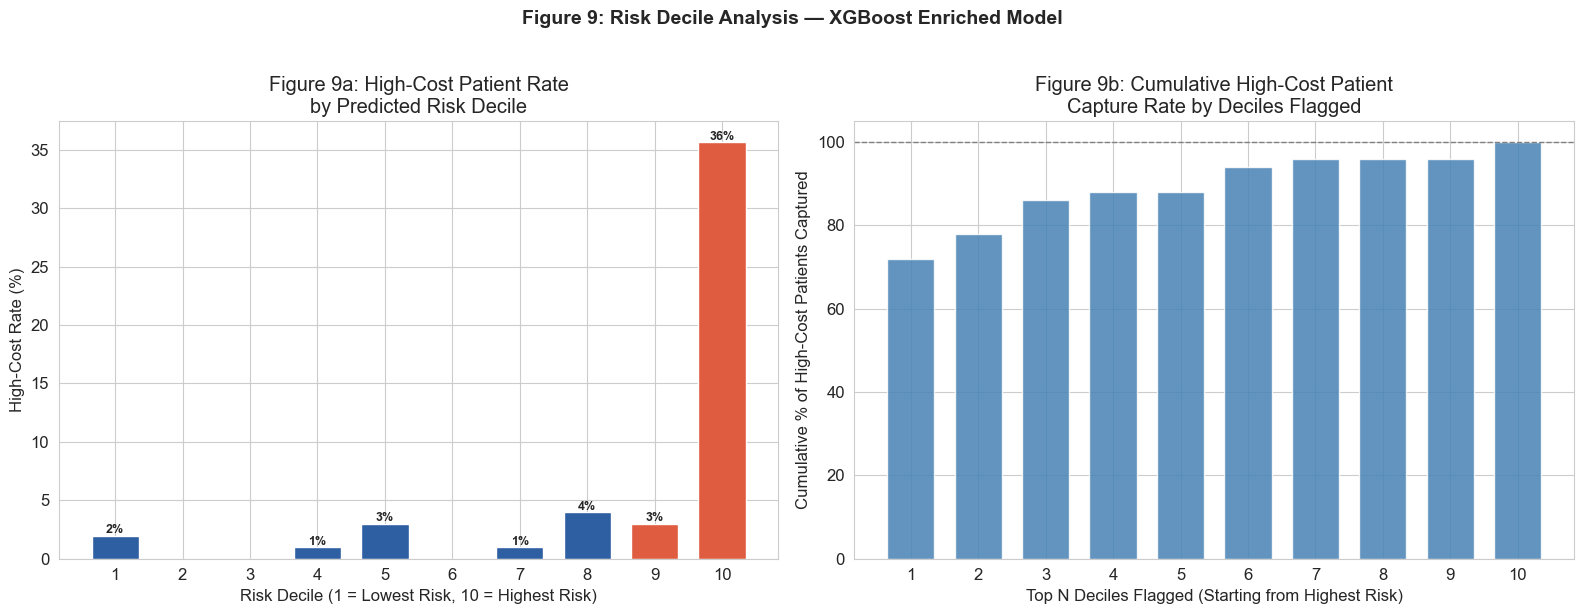

✓ Figure 9 saved

Decile Summary Table:
 DECILE  N_PATIENTS  N_HIGH_COST  HIGH_COST_RATE  CUMULATIVE_CAPTURE
      1         101            2        1.980198               100.0
      2         100            0        0.000000                96.0
      3         100            0        0.000000                96.0
      4         100            1        1.000000                96.0
      5         100            3        3.000000                94.0
      6         100            0        0.000000                88.0
      7         100            1        1.000000                88.0
      8         100            4        4.000000                86.0
      9         100            3        3.000000                78.0
     10         101           36       35.643564                72.0


In [21]:
# ── CELL 17: RISK DECILE ANALYSIS ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Build decile dataframe using best model (XGB enriched)
decile_df = pd.DataFrame({
    'TRUE_LABEL': y2_test.values,
    'PRED_PROBA': y2_xgb_proba,
    'Y2_SPEND': df_enriched.loc[y2_test.index, 'Y2_TOTAL_PMT'].values
})

decile_df['DECILE'] = pd.qcut(decile_df['PRED_PROBA'],
                               q=10, labels=False, duplicates='drop')
decile_df['DECILE'] = decile_df['DECILE'] + 1  # 1-10

# High cost capture rate per decile
decile_summary = decile_df.groupby('DECILE').agg(
    N_PATIENTS=('TRUE_LABEL', 'count'),
    N_HIGH_COST=('TRUE_LABEL', 'sum'),
    MEAN_SPEND=('Y2_SPEND', 'mean')
).reset_index()

total_high_cost = decile_summary['N_HIGH_COST'].sum()
decile_summary['PCT_HIGH_COST'] = decile_summary['N_HIGH_COST'] / total_high_cost * 100
decile_summary['CUMULATIVE_CAPTURE'] = decile_summary['PCT_HIGH_COST'][::-1].cumsum()[::-1]
decile_summary['HIGH_COST_RATE'] = (decile_summary['N_HIGH_COST'] /
                                     decile_summary['N_PATIENTS'] * 100)

# Left: High-cost rate by decile
colors = ['#E05C40' if d >= 9 else '#2E5FA3' for d in decile_summary['DECILE']]
bars = axes[0].bar(decile_summary['DECILE'], decile_summary['HIGH_COST_RATE'],
                   color=colors, edgecolor='white', width=0.7)
axes[0].set_xlabel('Risk Decile (1 = Lowest Risk, 10 = Highest Risk)')
axes[0].set_ylabel('High-Cost Rate (%)')
axes[0].set_title('Figure 9a: High-Cost Patient Rate\nby Predicted Risk Decile')
axes[0].set_xticks(range(1, 11))
for bar, val in zip(bars, decile_summary['HIGH_COST_RATE']):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold')

# Right: Cumulative capture curve
axes[1].bar(decile_summary['DECILE'][::-1].values,
            decile_summary['CUMULATIVE_CAPTURE'].values,
            color='steelblue', edgecolor='white', width=0.7, alpha=0.85)
axes[1].axhline(y=100, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('Top N Deciles Flagged (Starting from Highest Risk)')
axes[1].set_ylabel('Cumulative % of High-Cost Patients Captured')
axes[1].set_title('Figure 9b: Cumulative High-Cost Patient\nCapture Rate by Deciles Flagged')
axes[1].set_xticks(range(1, 11))

plt.suptitle('Figure 9: Risk Decile Analysis — XGBoost Enriched Model',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figure9_risk_decile.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure 9 saved")
print("\nDecile Summary Table:")
print(decile_summary[['DECILE','N_PATIENTS','N_HIGH_COST',
                        'HIGH_COST_RATE','CUMULATIVE_CAPTURE']].to_string(index=False))

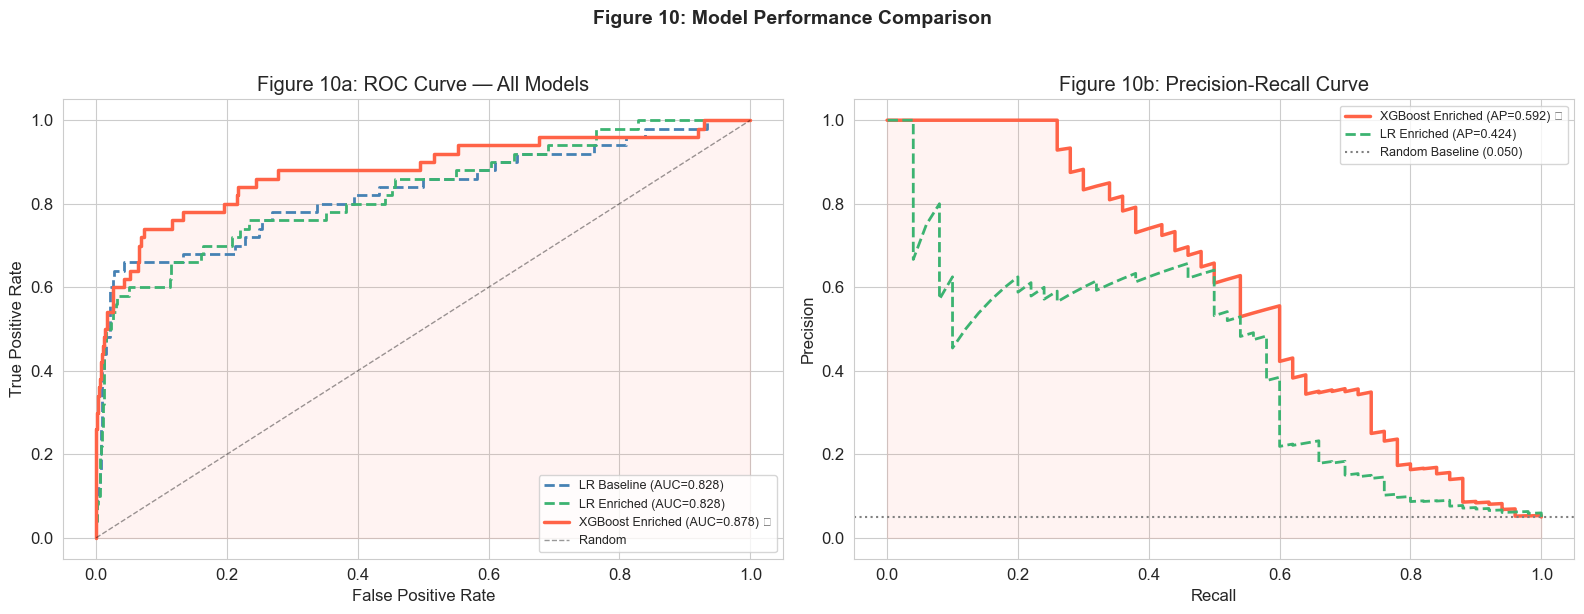

✓ Figure 10 saved
XGBoost AP Score: 0.5918
LR Enriched AP Score: 0.4236


In [22]:
# ── CELL 18: PRECISION-RECALL CURVE + ROC COMPARISON ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── ROC COMPARISON (all 4 models) ─────────────────────────────────────
# Recompute LR baseline probabilities
lr_base_proba = lr.predict_proba(X_test_sc)[:, 1]
fpr_lr_base, tpr_lr_base, _ = roc_curve(y_test, lr_base_proba)
fpr_lr2, tpr_lr2, _ = roc_curve(y2_test, y2_lr_proba)
fpr_xgb2, tpr_xgb2, _ = roc_curve(y2_test, y2_xgb_proba)

axes[0].plot(fpr_lr_base, tpr_lr_base, color='steelblue',
             lw=2, linestyle='--', label='LR Baseline (AUC=0.828)')
axes[0].plot(fpr_lr2, tpr_lr2, color='mediumseagreen',
             lw=2, linestyle='--', label=f'LR Enriched (AUC={lr2_auc:.3f})')
axes[0].plot(fpr_xgb2, tpr_xgb2, color='tomato',
             lw=2.5, label=f'XGBoost Enriched (AUC={xgb2_auc:.3f}) ★')
axes[0].plot([0,1],[0,1],'k--', lw=1, alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Figure 10a: ROC Curve — All Models')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].fill_between(fpr_xgb2, tpr_xgb2, alpha=0.07, color='tomato')

# ── PRECISION-RECALL CURVE ─────────────────────────────────────────────
pr_xgb2, rec_xgb2, _ = precision_recall_curve(y2_test, y2_xgb_proba)
pr_lr2, rec_lr2, _ = precision_recall_curve(y2_test, y2_lr_proba)
ap_xgb2 = average_precision_score(y2_test, y2_xgb_proba)
ap_lr2 = average_precision_score(y2_test, y2_lr_proba)

baseline_precision = y2_test.mean()

axes[1].plot(rec_xgb2, pr_xgb2, color='tomato', lw=2.5,
             label=f'XGBoost Enriched (AP={ap_xgb2:.3f}) ★')
axes[1].plot(rec_lr2, pr_lr2, color='mediumseagreen', lw=2,
             linestyle='--', label=f'LR Enriched (AP={ap_lr2:.3f})')
axes[1].axhline(y=baseline_precision, color='gray', linestyle=':',
                lw=1.5, label=f'Random Baseline ({baseline_precision:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Figure 10b: Precision-Recall Curve')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].fill_between(rec_xgb2, pr_xgb2, alpha=0.07, color='tomato')

plt.suptitle('Figure 10: Model Performance Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figure10_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure 10 saved")
print(f"XGBoost AP Score: {ap_xgb2:.4f}")
print(f"LR Enriched AP Score: {ap_lr2:.4f}")

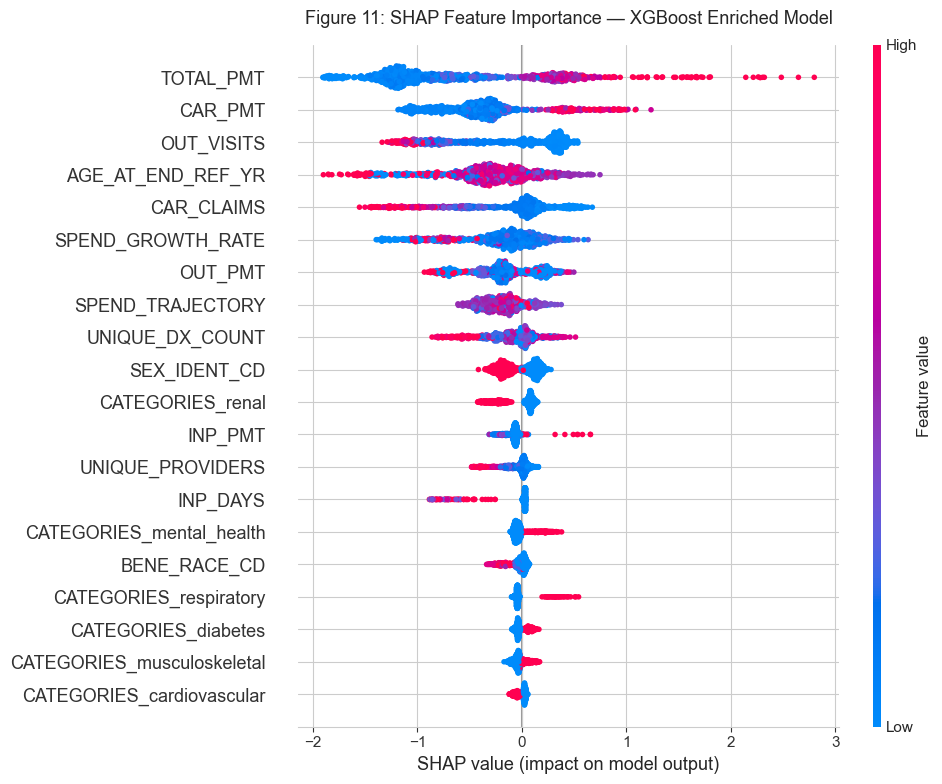

✓ Figure 11 saved


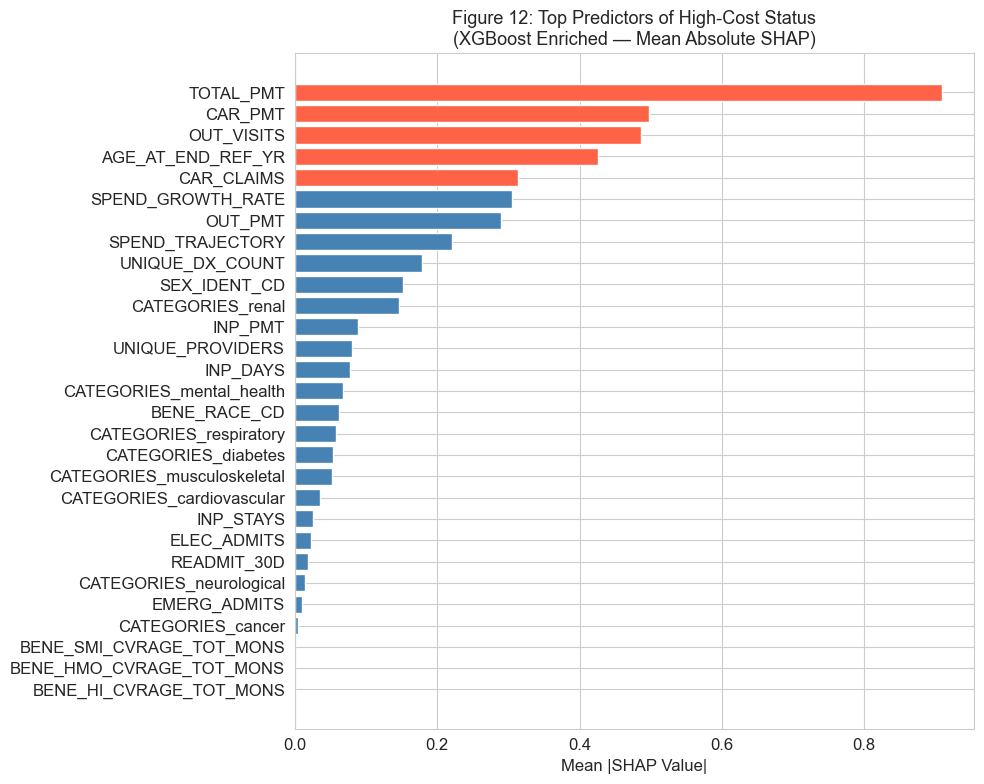

✓ Figure 12 saved

Top 10 features by SHAP importance:
          Feature  Mean_SHAP
        TOTAL_PMT   0.908719
          CAR_PMT   0.497707
       OUT_VISITS   0.486235
AGE_AT_END_REF_YR   0.425242
       CAR_CLAIMS   0.313951
SPEND_GROWTH_RATE   0.305011
          OUT_PMT   0.289863
 SPEND_TRAJECTORY   0.221174
  UNIQUE_DX_COUNT   0.178910
     SEX_IDENT_CD   0.152036

Highest-risk patient:
  Predicted probability: 0.9788
  Actual label (1=high-cost): 1


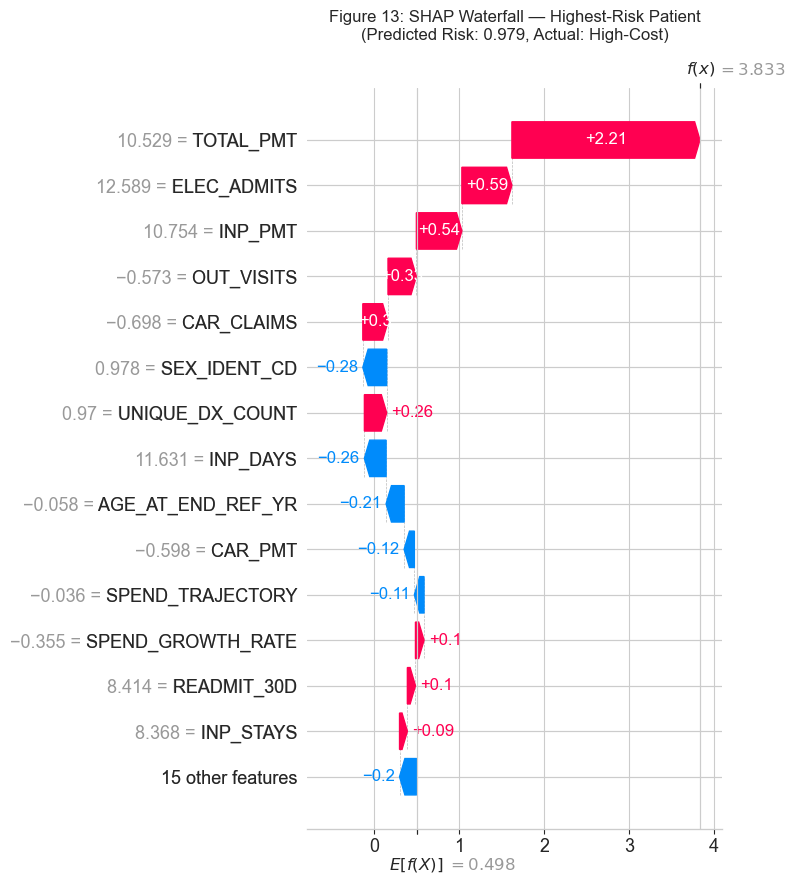

✓ Figure 13 saved


In [23]:
# ── CELL 19: SHAP ANALYSIS ON XGBOOST ENRICHED ────────────────────────
import shap

# SHAP explainer for XGBoost
explainer2 = shap.TreeExplainer(xgb2)
shap_values2 = explainer2.shap_values(X2_test_sc)

X2_test_display = pd.DataFrame(X2_test_sc, columns=feature_cols_v2)

# ── FIGURE 11: SHAP BEESWARM ───────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values2, X2_test_display,
                  feature_names=feature_cols_v2,
                  show=False, plot_size=(10, 8))
plt.title("Figure 11: SHAP Feature Importance — XGBoost Enriched Model",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../outputs/figure11_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 11 saved")

# ── FIGURE 12: SHAP BAR CHART ──────────────────────────────────────────
shap_df2 = pd.DataFrame({
    'Feature': feature_cols_v2,
    'Mean_SHAP': np.abs(shap_values2).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['tomato' if f in shap_df2.tail(5)['Feature'].values
          else 'steelblue' for f in shap_df2['Feature']]
ax.barh(shap_df2['Feature'], shap_df2['Mean_SHAP'],
        color=colors, edgecolor='white')
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Figure 12: Top Predictors of High-Cost Status\n(XGBoost Enriched — Mean Absolute SHAP)',
             fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figure12_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 12 saved")

print("\nTop 10 features by SHAP importance:")
print(shap_df2.tail(10)[['Feature','Mean_SHAP']].iloc[::-1].to_string(index=False))

# ── FIGURE 13: SHAP WATERFALL FOR ONE HIGH-RISK PATIENT ───────────────
# Find the highest-risk patient in test set
high_risk_idx = np.argmax(y2_xgb_proba)
true_label = y2_test.iloc[high_risk_idx]

print(f"\nHighest-risk patient:")
print(f"  Predicted probability: {y2_xgb_proba[high_risk_idx]:.4f}")
print(f"  Actual label (1=high-cost): {true_label}")

# Waterfall plot
shap_explanation = shap.Explanation(
    values=shap_values2[high_risk_idx],
    base_values=explainer2.expected_value,
    data=X2_test_sc[high_risk_idx],
    feature_names=feature_cols_v2
)

plt.figure(figsize=(12, 7))
shap.waterfall_plot(shap_explanation, max_display=15, show=False)
plt.title(f"Figure 13: SHAP Waterfall — Highest-Risk Patient\n"
          f"(Predicted Risk: {y2_xgb_proba[high_risk_idx]:.3f}, "
          f"Actual: {'High-Cost' if true_label==1 else 'Not High-Cost'})",
          fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('../outputs/figure13_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 13 saved")

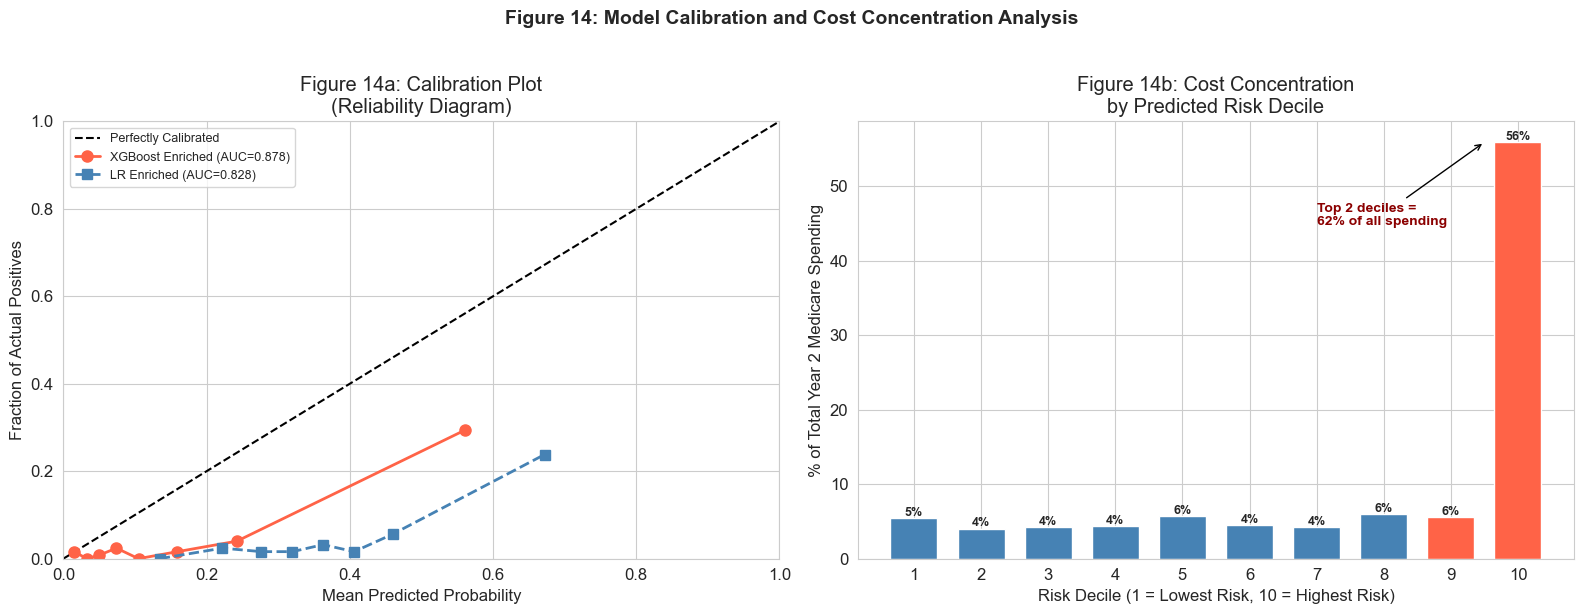

✓ Figure 14 saved

Cost concentration by top deciles:
  Top decile (10) accounts for: 55.9% of spending
  Top 2 deciles (9-10) account for: 61.5% of spending
  Top 3 deciles (8-10) account for: 67.5% of spending


In [24]:
# ── CELL 20: CALIBRATION PLOT + COST CONCENTRATION ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── CALIBRATION PLOT ───────────────────────────────────────────────────
from sklearn.calibration import calibration_curve

# XGBoost enriched calibration
frac_pos_xgb, mean_pred_xgb = calibration_curve(
    y2_test, y2_xgb_proba, n_bins=8, strategy='quantile')

# LR enriched calibration
frac_pos_lr, mean_pred_lr = calibration_curve(
    y2_test, y2_lr_proba, n_bins=8, strategy='quantile')

axes[0].plot([0,1],[0,1], 'k--', lw=1.5, label='Perfectly Calibrated')
axes[0].plot(mean_pred_xgb, frac_pos_xgb, 'o-', color='tomato',
             lw=2, markersize=8, label=f'XGBoost Enriched (AUC={xgb2_auc:.3f})')
axes[0].plot(mean_pred_lr, frac_pos_lr, 's--', color='steelblue',
             lw=2, markersize=7, label=f'LR Enriched (AUC={lr2_auc:.3f})')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Actual Positives')
axes[0].set_title('Figure 14a: Calibration Plot\n(Reliability Diagram)')
axes[0].legend(fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# ── COST CONCENTRATION BY RISK DECILE ─────────────────────────────────
decile_spend = decile_df.groupby('DECILE').agg(
    TOTAL_SPEND=('Y2_SPEND', 'sum')
).reset_index()

total_spend_all = decile_spend['TOTAL_SPEND'].sum()
decile_spend['PCT_SPEND'] = decile_spend['TOTAL_SPEND'] / total_spend_all * 100
decile_spend['CUMULATIVE_SPEND'] = decile_spend['PCT_SPEND'][::-1].cumsum()[::-1]

colors2 = ['tomato' if d >= 9 else 'steelblue' for d in decile_spend['DECILE']]
bars2 = axes[1].bar(decile_spend['DECILE'], decile_spend['PCT_SPEND'],
                    color=colors2, edgecolor='white', width=0.7)
axes[1].set_xlabel('Risk Decile (1 = Lowest Risk, 10 = Highest Risk)')
axes[1].set_ylabel('% of Total Year 2 Medicare Spending')
axes[1].set_title('Figure 14b: Cost Concentration\nby Predicted Risk Decile')
axes[1].set_xticks(range(1, 11))
for bar, val in zip(bars2, decile_spend['PCT_SPEND']):
    if val > 1:
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3,
                     f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold')

# Annotation
top2_spend = decile_spend[decile_spend['DECILE'] >= 9]['PCT_SPEND'].sum()
axes[1].annotate(f'Top 2 deciles =\n{top2_spend:.0f}% of all spending',
                 xy=(9.5, decile_spend[decile_spend['DECILE']==10]['PCT_SPEND'].values[0]),
                 xytext=(7, decile_spend['PCT_SPEND'].max() * 0.8),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=10, color='darkred', fontweight='bold')

plt.suptitle('Figure 14: Model Calibration and Cost Concentration Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figure14_calibration_cost.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure 14 saved")
print(f"\nCost concentration by top deciles:")
print(f"  Top decile (10) accounts for: {decile_spend[decile_spend['DECILE']==10]['PCT_SPEND'].values[0]:.1f}% of spending")
print(f"  Top 2 deciles (9-10) account for: {top2_spend:.1f}% of spending")
print(f"  Top 3 deciles (8-10) account for: {decile_spend[decile_spend['DECILE']>=8]['PCT_SPEND'].sum():.1f}% of spending")